(6362620, 11)
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703

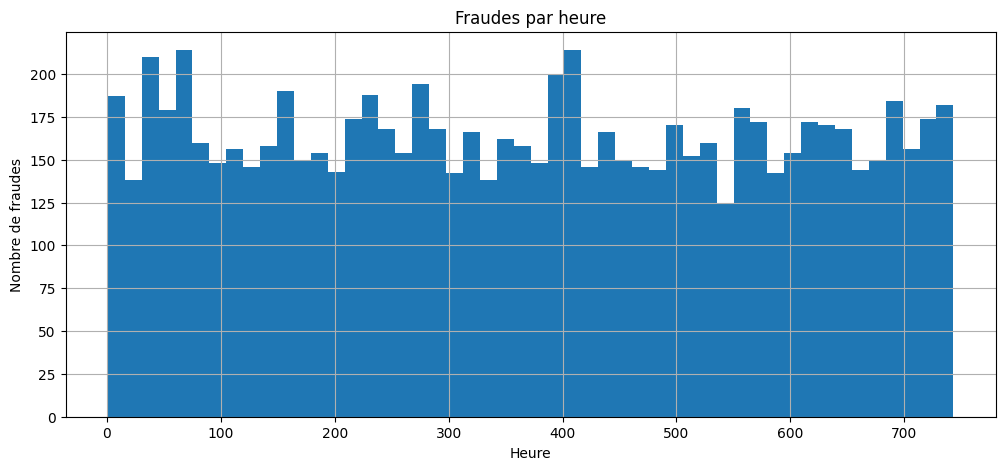

In [26]:
#on importe les outils nécessaires pour utiliser les tableaux de données 
import pandas as pd

#on va lire le csv et le stocker dans une variable df
df = pd.read_csv("data/PS_20174392719_1491204439457_log.csv")

#une ligne qui affice les dimensions du tableau de données
print(df.shape)
#Le nombre de transactions
nb_transactions=df.shape[0]

#une ligne qui affiche les colonnes du tableau
print(df.columns.tolist())

#une ligne qui affiche les 5 premières lignes du tableau
print(df.head())

#on va compter le nombre de fraudes
nb_fraudes=(df[df["isFraud"] == 1].shape[0])
print(nb_fraudes)

#on va exprimer en pourcentage le nombre de fraudes
pourcentage_fraudes = nb_fraudes/nb_transactions * 100
print(pourcentage_fraudes)

#les différents types de transactions
df["type"].value_counts()

#on va compter le nombre de fraudes par type de transaction
df[df["isFraud"]==1]["type"].value_counts()

import matplotlib.pyplot as plt
# on filtre uniquement les fraudes
fraudes = df[df['isFraud'] == 1]

# on trace un histogramme des fraudes par heure
plt.figure(figsize=(12, 5))
fraudes['step'].hist(bins=50)
plt.title('Fraudes par heure')
plt.xlabel('Heure')
plt.ylabel('Nombre de fraudes')
plt.show()


In [31]:
# statistiques sur les montants des transactions normales
df[df['isFraud'] == 0]['amount'].describe()



count    6.354407e+06
mean     1.781970e+05
std      5.962370e+05
min      1.000000e-02
25%      1.336840e+04
50%      7.468472e+04
75%      2.083648e+05
max      9.244552e+07
Name: amount, dtype: float64

In [30]:
# statistiques sur les montants des transactions frauduleuses
df[df["isFraud"]==1]["amount"].describe()

count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64

In [32]:
# compter les fraudes où le solde final est 0
df[(df['isFraud']==1) & (df['newbalanceOrig']==0)].shape[0]

8053

In [ ]:
# on importe seaborn pour des graphiques plus jolis
import seaborn as sns

type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64

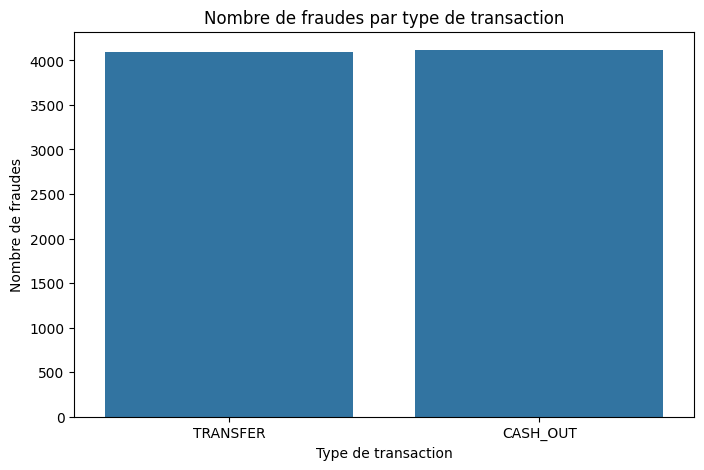

In [35]:
# on filtre uniquement les fraudes
fraudes = df[df['isFraud'] == 1]

# on crée un graphique en barres des fraudes par type
plt.figure(figsize=(8, 5))
sns.countplot(data=fraudes, x='type')
plt.title('Nombre de fraudes par type de transaction')
plt.xlabel('Type de transaction')
plt.ylabel('Nombre de fraudes')
plt.show()

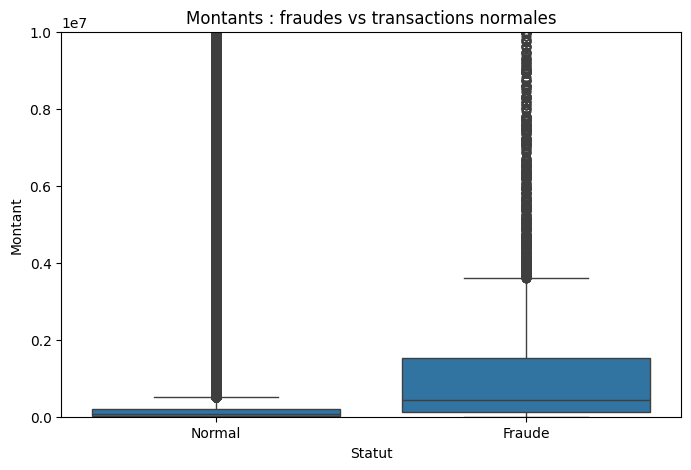

In [37]:
# on crée une colonne texte pour distinguer fraude et normal
df['statut'] = df['isFraud'].map({0: 'Normal', 1: 'Fraude'})

# boxplot comparant les montants entre fraudes et transactions normales
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='statut', y='amount')
plt.title('Montants : fraudes vs transactions normales')
plt.xlabel('Statut')
plt.ylabel('Montant')
plt.ylim(0, 10000000)
plt.show()

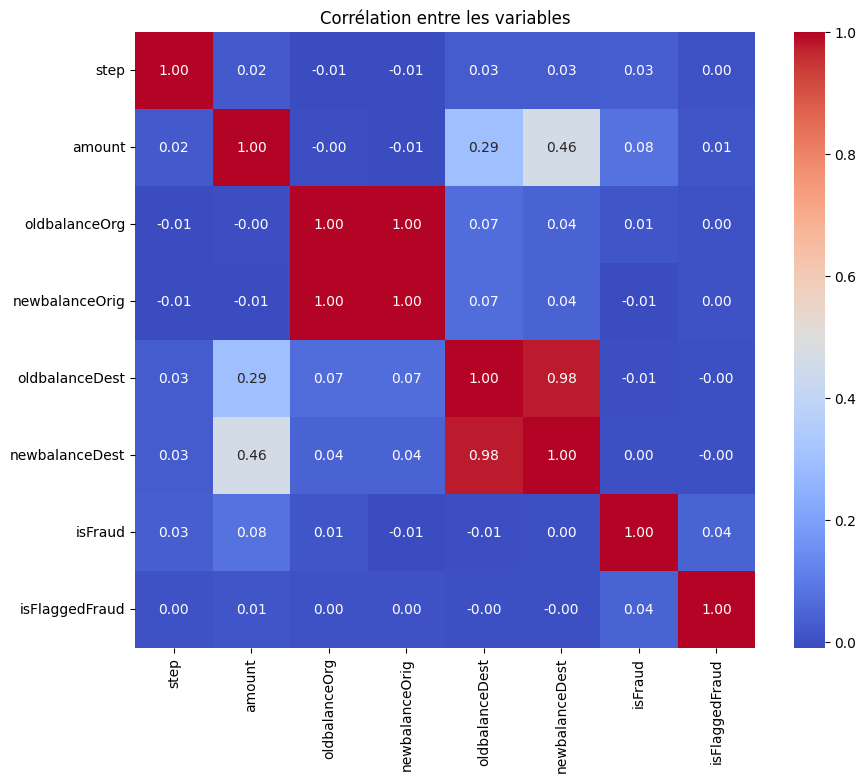

In [38]:
# on calcule la corrélation entre toutes les colonnes numériques
correlation = df.corr(numeric_only=True)

# on affiche la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Corrélation entre les variables')
plt.show()